Uncovering Purchase Patterns with Association Rule Mining

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install apyori mlxtend -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
from apyori import apriori
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Market_Basket_Optimisation.csv', header = None)

In [ ]:
dataset

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Exploratory Data Analysis (EDA)

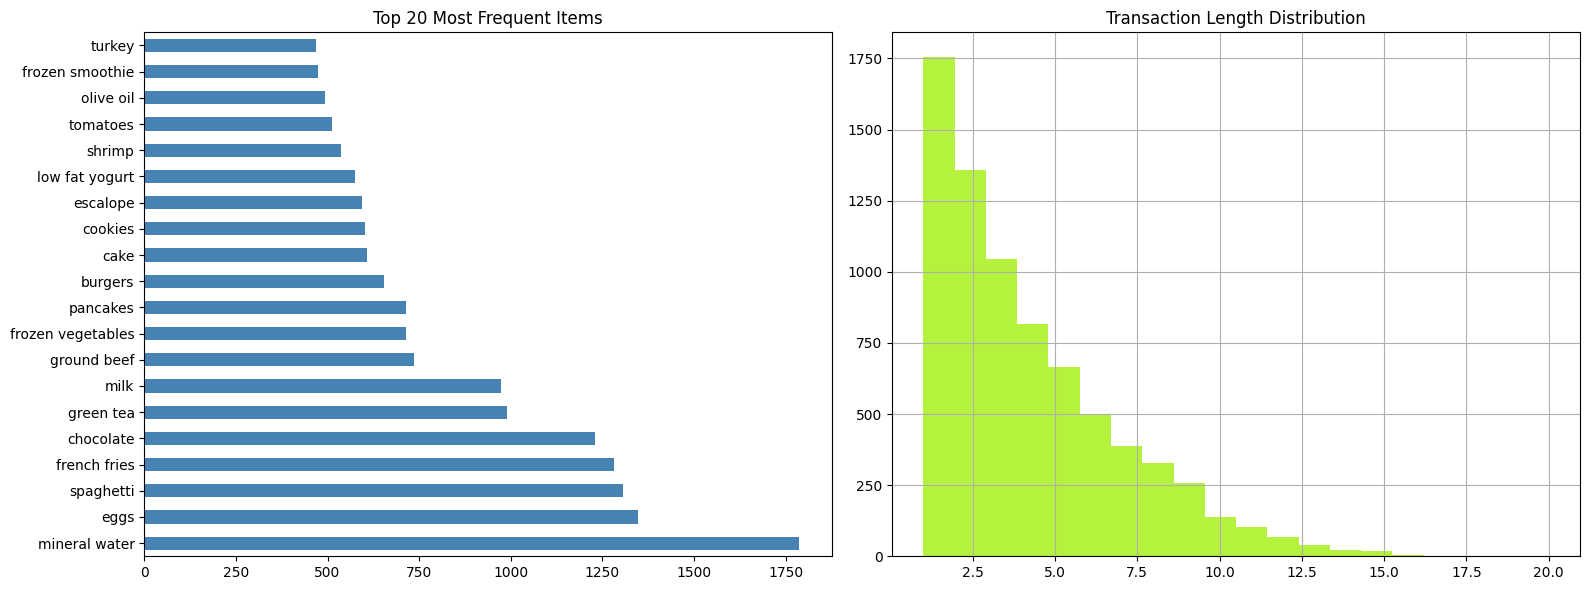

Avg items per transaction: 3.91


In [ ]:
all_items = dataset.values.flatten()
item_freq = pd.Series(all_items).dropna()
item_freq = item_freq[item_freq != 'nan'].value_counts().head(20)

tx_lengths = dataset.apply(lambda r: r.notna().sum(), axis=1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

item_freq.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Most Frequent Items')

tx_lengths.hist(bins=20, ax=axes[1], color='#b5f23d')
axes[1].set_title('Transaction Length Distribution')

plt.tight_layout()
plt.show()

print(f"Avg items per transaction: {tx_lengths.mean():.2f}")

Apriori Algorithm

Data Preprocessing

In [ ]:
transactions = dataset.apply(
    lambda row: [item for item in row if pd.notna(item)],
    axis=1
).tolist()

print(f"Transactions ready: {len(transactions)}")
print(f"Sample: {transactions[0]}")

Transactions ready: 7501
Sample: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']


Apriori Function & Results

In [ ]:
def run_apriori(transactions, min_support=0.003, min_confidence=0.2, min_lift=3):
    raw = list(apriori(transactions, min_support=min_support,
                       min_confidence=min_confidence, min_lift=min_lift,
                       min_length=2, max_length=2))

    if not raw:
        print("No rules found.")
        return pd.DataFrame()

    rows = [(tuple(r[2][0][0])[0], tuple(r[2][0][1])[0],
             r[1], r[2][0][2], r[2][0][3]) for r in raw]

    df = pd.DataFrame(rows, columns=['LHS', 'RHS', 'Support', 'Confidence', 'Lift'])
    return df.sort_values('Lift', ascending=False).reset_index(drop=True)

df = run_apriori(transactions)
print(f"Rules found: {len(df)}")
df

Rules found: 9


,LHS,RHS,Support,Confidence,Lift
0,fromage blanc,honey,0.003333,0.245098,5.164271
1,light cream,chicken,0.004533,0.290598,4.843951
2,pasta,escalope,0.005866,0.372881,4.700812
3,pasta,shrimp,0.005066,0.322034,4.506672
4,whole wheat pasta,olive oil,0.007999,0.271493,4.122410
5,tomato sauce,ground beef,0.005333,0.377358,3.840659
6,mushroom cream sauce,escalope,0.005733,0.300699,3.790833
7,herb & pepper,ground beef,0.015998,0.323450,3.291994
8,light cream,olive oil,0.003200,0.205128,3.114710


Visualization of Results

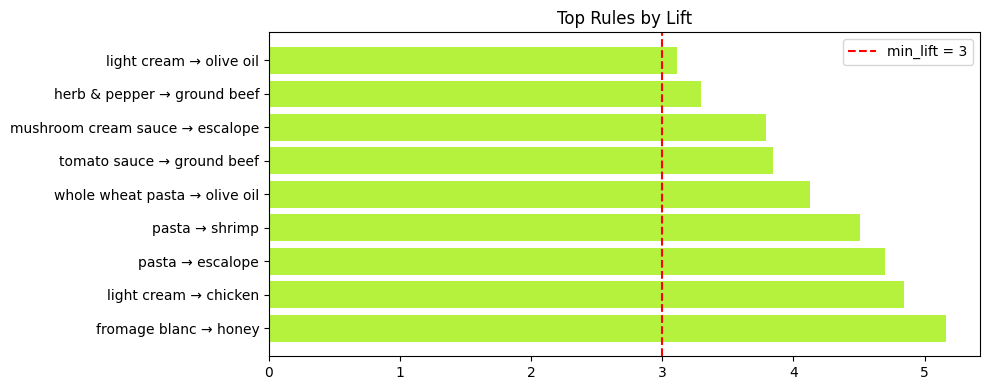

In [ ]:
labels = [f"{r.LHS} → {r.RHS}" for _, r in df.iterrows()]

plt.figure(figsize=(10, 4))
plt.barh(labels, df['Lift'], color='#b5f23d')
plt.axvline(3, color='red', ls='--', label='min_lift = 3')
plt.title('Top Rules by Lift')
plt.legend()
plt.tight_layout()
plt.show()

FP-Growth

Data Preprocessing

In [ ]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

df_encoded

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


FP-Growth Results

In [ ]:
frequent_itemsets = fpgrowth(df_encoded, min_support=0.003, use_colnames=True)

df_fpgrowth = association_rules(frequent_itemsets, metric='lift', min_threshold=3)
df_fpgrowth = df_fpgrowth[
    (df_fpgrowth['antecedents'].apply(len) == 1) &
    (df_fpgrowth['consequents'].apply(len) == 1)
]
df_fpgrowth = df_fpgrowth[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

df_fpgrowth = df_fpgrowth.sort_values('confidence', ascending=False)
df_fpgrowth['pair'] = df_fpgrowth.apply(
    lambda r: frozenset([list(r.antecedents)[0], list(r.consequents)[0]]), axis=1
)
df_fpgrowth = df_fpgrowth.drop_duplicates(subset='pair').drop(columns='pair')
df_fpgrowth = df_fpgrowth.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Rules found: {len(df_fpgrowth)}")
df_fpgrowth

Rules found: 12


,antecedents,consequents,support,confidence,lift
0,(fromage blanc),(honey),0.003333,0.245098,5.164271
1,(light cream),(chicken),0.004533,0.290598,4.843951
2,(pasta),(escalope),0.005866,0.372881,4.700812
3,(pasta),(shrimp),0.005066,0.322034,4.506672
4,(whole wheat pasta),(olive oil),0.007999,0.271493,4.122410
5,(tomato sauce),(ground beef),0.005333,0.377358,3.840659
6,(mushroom cream sauce),(escalope),0.005733,0.300699,3.790833
7,(fresh tuna),(honey),0.003999,0.179641,3.785070
8,(herb & pepper),(ground beef),0.015998,0.323450,3.291994
9,(tomato juice),(fresh bread),0.004266,0.140351,3.259356


Visualization of Results

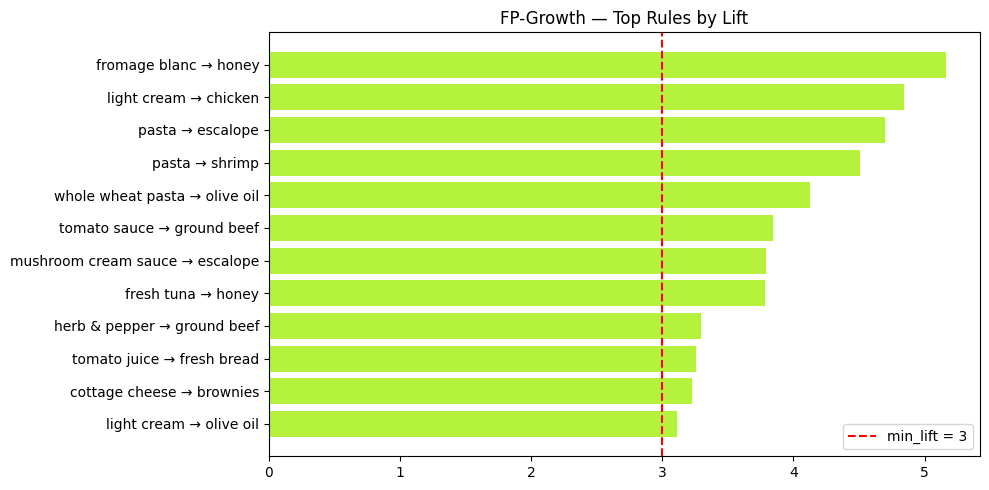

In [ ]:
df_plot = df_fpgrowth.sort_values('lift', ascending=True)

labels = [f"{list(r.antecedents)[0]} → {list(r.consequents)[0]}" for _, r in df_plot.iterrows()]

plt.figure(figsize=(10, 5))
plt.barh(labels, df_plot['lift'], color='#b5f23d')
plt.axvline(3, color='red', ls='--', label='min_lift = 3')
plt.title('FP-Growth — Top Rules by Lift')
plt.legend()
plt.tight_layout()
plt.show()

Algorithm Comparison

In [ ]:
apriori_rules = set(zip(df['LHS'], df['RHS']))

fpgrowth_rules = set(zip(
    df_fpgrowth['antecedents'].apply(lambda x: list(x)[0]),
    df_fpgrowth['consequents'].apply(lambda x: list(x)[0])
))

common = apriori_rules & fpgrowth_rules

only_fpgrowth = fpgrowth_rules - apriori_rules

print(f"Total Apriori rules:   {len(apriori_rules)}")
print(f"Total FP-Growth rules: {len(fpgrowth_rules)}")
print(f"Common rules:          {len(common)}")
print(f"\nRules only in FP-Growth:")
for lhs, rhs in only_fpgrowth:
    print(f"  {lhs} → {rhs}")

Total Apriori rules:   9
Total FP-Growth rules: 12
Common rules:          9

Rules only in FP-Growth:
  fresh tuna → honey
  cottage cheese → brownies
  tomato juice → fresh bread
